# 10 — Évaluation rigoureuse de la qualité des explications XAI

## 🎯 Objectif

Évaluer **objectivement** la qualité des explications SHAP et LIME selon 3 dimensions standard de la littérature XAI :

1. **Stabilité** — l'explication est-elle reproductible ?
2. **Fidélité** — l'explication reflète-t-elle vraiment le modèle ?
3. **Plausibilité** — l'explication a-t-elle du sens cyber ?

## Question scientifique

> **"Quelle méthode XAI recommander à un analyste SOC ?"**

Le but de ce notebook est de fournir une **recommandation argumentée** par des métriques quantitatives, pas une opinion.

## 📋 Plan

1. Setup + chargement (modèle, SHAP, LIME)
2. **Métrique 1 : Stabilité** (Jaccard sur runs répétés)
3. **Métrique 2 : Fidélité** (AOPC — Area Over Perturbation Curve)
4. **Métrique 3 : Plausibilité** (coverage par features cyber-signatures)
5. **Synthèse** : tableau comparatif + recommandation finale

## ⏱️ Temps estimé

**~15-20 min**. Le plus long est la stabilité de LIME (3 runs × 30 cas).

## 1. Setup et chargement

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from time import time

from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')
RESULTS_XAI = Path('../results/xai')

SEED = 42
np.random.seed(SEED)

print('✅ Setup terminé')

✅ Setup terminé


In [7]:
# Modèle XGBoost
xgb_model = joblib.load(RESULTS_MODELS / 'xgb_optimized.joblib')

# Données
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values.astype(np.float32)

# Splits
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    stratify=y_trainval, random_state=SEED,
)

# Sample SHAP existant
shap_data = np.load(RESULTS_XAI / 'shap_values_xgb.npz')
shap_values = shap_data['shap_values']
X_sample = shap_data['X_sample']
y_sample = shap_data['y_sample']
y_sample_pred = shap_data['y_sample_pred']

# LIME background
bg_indices = np.random.choice(len(X_train), 5000, replace=False)
X_background = X_train[bg_indices]
background_mean = X_train.mean(axis=0)  # pour les perturbations de fidélité

# LIME explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_background,
    feature_names=feature_cols,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
    random_state=None,    # ⭐ pour la stabilité, on veut justement de l'aléa
)

print(f'✅ Tout chargé')
print(f'   Sample SHAP : {X_sample.shape}')
print(f'   SHAP values : {shap_values.shape}')

✅ Tout chargé
   Sample SHAP : (5123, 77)
   SHAP values : (5123, 77, 7)


In [8]:
def extract_lime_feature_names(lime_contribs):
    """Extrait les noms de features purs depuis les descriptions LIME."""
    feature_names = []
    for desc, _ in lime_contribs:
        matched = None
        for fc in feature_cols:
            if fc in desc:
                if matched is None or len(fc) > len(matched):
                    matched = fc
        feature_names.append(matched if matched else desc)
    return feature_names


def get_shap_top_features(case_idx, top_k=10):
    """Retourne les top-k features SHAP (indices) pour un cas donné."""
    pred_class = int(y_sample_pred[case_idx])
    shap_vals = shap_values[case_idx, :, pred_class]
    top_idx = np.argsort(np.abs(shap_vals))[-top_k:][::-1]
    return top_idx, [feature_cols[i] for i in top_idx], shap_vals


def get_lime_top_features(case_idx, top_k=10):
    """Calcule les top-k features LIME (indices) pour un cas donné."""
    pred_class = int(y_sample_pred[case_idx])
    exp = explainer_lime.explain_instance(
        data_row=X_sample[case_idx],
        predict_fn=xgb_model.predict_proba,
        num_features=top_k,
        labels=[pred_class],
    )
    contribs = exp.as_list(label=pred_class)
    feat_names = extract_lime_feature_names(contribs)
    feat_indices = []
    for fn in feat_names:
        if fn in feature_cols:
            feat_indices.append(feature_cols.index(fn))
    return np.array(feat_indices), feat_names, contribs

print('✅ Fonctions utilitaires définies')

✅ Fonctions utilitaires définies


## 2. Métrique 1 : STABILITÉ

### 📚 Méthodologie

Pour chaque méthode et chaque cas, on exécute **3 fois** l'explication, puis on compare les top-10 features obtenues entre les runs.

**Métrique** : **Jaccard similarity moyenne** entre les paires de runs.

$$
Jaccard(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

- 1,0 = identique
- 0,0 = complètement différent

Note : **SHAP TreeExplainer est déterministe** — on s'attend à 1,0 trivialement. C'est LIME qui constitue le vrai test.

In [9]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else 0

# 30 cas tirés aléatoirement
n_stability_cases = 30
stability_indices = np.random.choice(len(X_sample), n_stability_cases, replace=False)

print(f'🔬 Test de stabilité sur {n_stability_cases} cas (3 runs par cas)\n')

shap_stability = []
lime_stability = []

t0 = time()
for i, idx in enumerate(stability_indices):
    # SHAP — 3 runs (devrait être déterministe)
    shap_runs = []
    for r in range(3):
        _, top, _ = get_shap_top_features(idx, top_k=10)
        shap_runs.append(top)
    
    # LIME — 3 runs (devrait varier)
    lime_runs = []
    for r in range(3):
        _, top, _ = get_lime_top_features(idx, top_k=10)
        lime_runs.append(top)
    
    # Jaccard entre paires (pour chaque méthode)
    shap_jac = np.mean([jaccard(shap_runs[a], shap_runs[b]) 
                         for a in range(3) for b in range(a+1, 3)])
    lime_jac = np.mean([jaccard(lime_runs[a], lime_runs[b]) 
                         for a in range(3) for b in range(a+1, 3)])
    
    shap_stability.append(shap_jac)
    lime_stability.append(lime_jac)
    
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{n_stability_cases} traités ({time()-t0:.1f}s)')

shap_stability = np.array(shap_stability)
lime_stability = np.array(lime_stability)

print(f'\n✅ Stabilité calculée en {(time()-t0)/60:.1f} min')
print('=' * 60)
print(f'  STABILITÉ (Jaccard moyenne)')
print('=' * 60)
print(f'  SHAP : {shap_stability.mean():.4f}  (min={shap_stability.min():.4f}, max={shap_stability.max():.4f})')
print(f'  LIME : {lime_stability.mean():.4f}  (min={lime_stability.min():.4f}, max={lime_stability.max():.4f})')

🔬 Test de stabilité sur 30 cas (3 runs par cas)

  10/30 traités (4.8s)
  20/30 traités (9.1s)
  30/30 traités (13.4s)

✅ Stabilité calculée en 0.2 min
  STABILITÉ (Jaccard moyenne)
  SHAP : 1.0000  (min=1.0000, max=1.0000)
  LIME : 0.5649  (min=0.4286, max=0.8182)


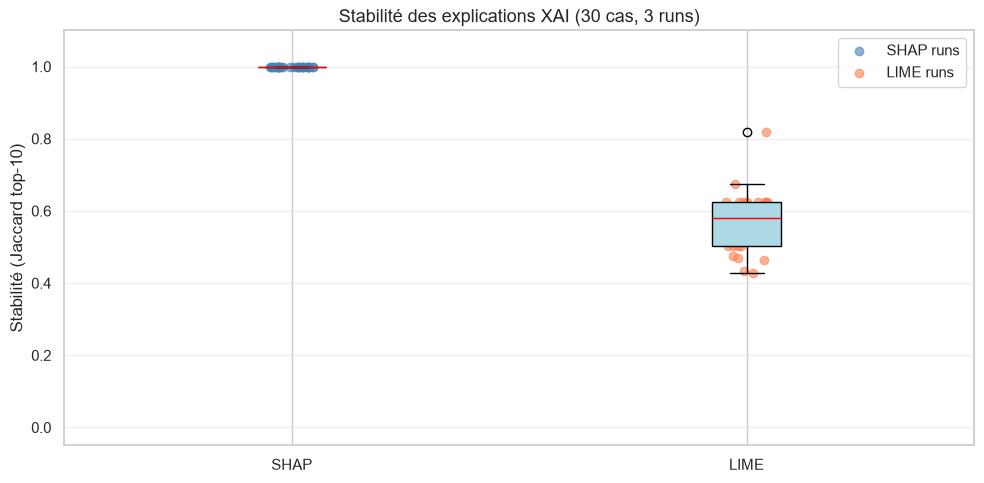

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([shap_stability, lime_stability], tick_labels=['SHAP', 'LIME'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
ax.scatter(np.ones_like(shap_stability) + np.random.uniform(-0.05, 0.05, len(shap_stability)),
            shap_stability, color='steelblue', alpha=0.6, label='SHAP runs')
ax.scatter(2*np.ones_like(lime_stability) + np.random.uniform(-0.05, 0.05, len(lime_stability)),
            lime_stability, color='coral', alpha=0.6, label='LIME runs')
ax.set_ylabel('Stabilité (Jaccard top-10)')
ax.set_title(f'Stabilité des explications XAI ({n_stability_cases} cas, 3 runs)', fontsize=13)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '10_xai_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Métrique 2 : FIDÉLITÉ (AOPC)

### 📚 Méthodologie

Pour chaque cas, on :
1. Note la probabilité de la classe prédite par XGBoost
2. Identifie le top-10 des features selon la méthode XAI (SHAP ou LIME)
3. Pour k = 1, 2, ..., 10 :
   - Remplace les k premières features par leur **valeur moyenne** (background)
   - Mesure la nouvelle probabilité
   - Calcule la chute : `delta_k = prob_original - prob_perturbée`
4. **AOPC** = moyenne des delta_k pour k=1..10

**Plus l'AOPC est élevé, plus l'explication est fidèle** (les features identifiées sont effectivement importantes pour le modèle).

### 📚 Pourquoi cette métrique fonctionne

Imagine deux explications pour la même prédiction :
- Explication X dit : *"Destination Port, Flow Duration, Total Packets sont les top features"*
- Explication Y dit : *"PSH Flag, URG Flag, ECE Flag sont les top features"*

Si on perturbe les top-3 features X et que la prédiction chute beaucoup → explication X **fidèle**.
Si on perturbe les top-3 features Y et que rien ne bouge → explication Y était **bidon**.

In [11]:
def compute_aopc(x_instance, top_feat_indices, pred_class, n_steps=10):
    """Calcule l'AOPC en perturbant successivement les top-k features."""
    orig_proba = xgb_model.predict_proba(x_instance.reshape(1, -1))[0, pred_class]
    
    x_perturbed = x_instance.copy()
    drops = []
    for k in range(min(n_steps, len(top_feat_indices))):
        feat_idx = top_feat_indices[k]
        x_perturbed[feat_idx] = background_mean[feat_idx]
        new_proba = xgb_model.predict_proba(x_perturbed.reshape(1, -1))[0, pred_class]
        drops.append(orig_proba - new_proba)
    return np.array(drops), orig_proba

# 100 cas pour la fidélité
n_fidelity_cases = 100
fidelity_indices = np.random.choice(len(X_sample), n_fidelity_cases, replace=False)

print(f'🔬 Test de fidélité sur {n_fidelity_cases} cas\n')

shap_aopc_curves = []
lime_aopc_curves = []
shap_aopc_means = []
lime_aopc_means = []

t0 = time()
for i, idx in enumerate(fidelity_indices):
    pred_class = int(y_sample_pred[idx])
    
    # SHAP
    shap_top_idx, _, _ = get_shap_top_features(idx, top_k=10)
    shap_drops, _ = compute_aopc(X_sample[idx], shap_top_idx, pred_class)
    shap_aopc_curves.append(shap_drops)
    shap_aopc_means.append(shap_drops.mean())
    
    # LIME
    lime_top_idx, _, _ = get_lime_top_features(idx, top_k=10)
    if len(lime_top_idx) > 0:
        lime_drops, _ = compute_aopc(X_sample[idx], lime_top_idx, pred_class)
        # Pad si moins de 10 features
        if len(lime_drops) < 10:
            lime_drops = np.pad(lime_drops, (0, 10 - len(lime_drops)), constant_values=lime_drops[-1])
        lime_aopc_curves.append(lime_drops)
        lime_aopc_means.append(lime_drops.mean())
    
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{n_fidelity_cases} traités ({time()-t0:.1f}s)')

shap_aopc_curves = np.array(shap_aopc_curves)
lime_aopc_curves = np.array(lime_aopc_curves)
shap_aopc_means = np.array(shap_aopc_means)
lime_aopc_means = np.array(lime_aopc_means)

print(f'\n✅ Fidélité calculée en {(time()-t0)/60:.1f} min')
print('=' * 60)
print(f'  FIDÉLITÉ (AOPC moyenne)')
print('=' * 60)
print(f'  SHAP : {shap_aopc_means.mean():.4f}')
print(f'  LIME : {lime_aopc_means.mean():.4f}')

🔬 Test de fidélité sur 100 cas

  20/100 traités (5.1s)
  40/100 traités (10.2s)
  60/100 traités (14.9s)
  80/100 traités (19.6s)
  100/100 traités (24.5s)

✅ Fidélité calculée en 0.4 min
  FIDÉLITÉ (AOPC moyenne)
  SHAP : 0.1186
  LIME : 0.1150


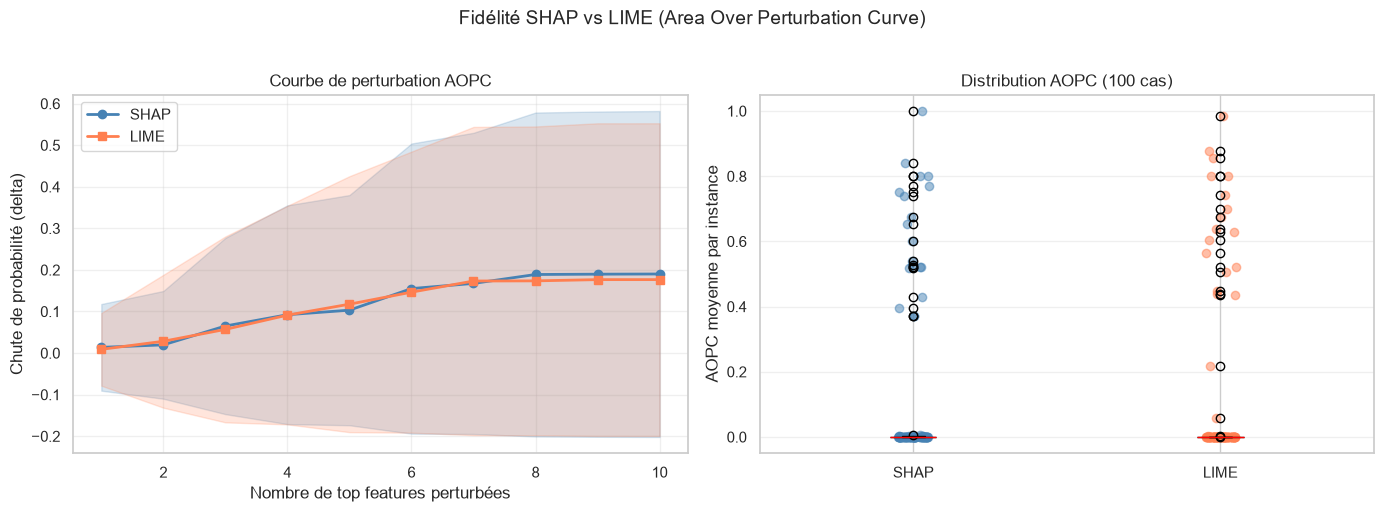

In [12]:
# Visualisation : courbes AOPC moyennes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes AOPC moyennes
x_steps = np.arange(1, 11)
shap_mean_curve = shap_aopc_curves.mean(axis=0)
lime_mean_curve = lime_aopc_curves.mean(axis=0)
shap_std_curve = shap_aopc_curves.std(axis=0)
lime_std_curve = lime_aopc_curves.std(axis=0)

axes[0].plot(x_steps, shap_mean_curve, 'o-', color='steelblue', label='SHAP', linewidth=2)
axes[0].fill_between(x_steps, shap_mean_curve - shap_std_curve, shap_mean_curve + shap_std_curve,
                       color='steelblue', alpha=0.2)
axes[0].plot(x_steps, lime_mean_curve, 's-', color='coral', label='LIME', linewidth=2)
axes[0].fill_between(x_steps, lime_mean_curve - lime_std_curve, lime_mean_curve + lime_std_curve,
                       color='coral', alpha=0.2)
axes[0].set_xlabel('Nombre de top features perturbées')
axes[0].set_ylabel('Chute de probabilité (delta)')
axes[0].set_title('Courbe de perturbation AOPC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot des AOPC moyens
axes[1].boxplot([shap_aopc_means, lime_aopc_means], tick_labels=['SHAP', 'LIME'],
                 patch_artist=True, boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='red'))
axes[1].scatter(np.ones_like(shap_aopc_means) + np.random.uniform(-0.05, 0.05, len(shap_aopc_means)),
                 shap_aopc_means, color='steelblue', alpha=0.5)
axes[1].scatter(2*np.ones_like(lime_aopc_means) + np.random.uniform(-0.05, 0.05, len(lime_aopc_means)),
                 lime_aopc_means, color='coral', alpha=0.5)
axes[1].set_ylabel('AOPC moyenne par instance')
axes[1].set_title(f'Distribution AOPC ({n_fidelity_cases} cas)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Fidélité SHAP vs LIME (Area Over Perturbation Curve)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '10_xai_fidelity_aopc.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Métrique 3 : PLAUSIBILITÉ

### 📚 Méthodologie

On définit une liste de **features cyber-pertinentes** par classe d'attaque, basée sur la littérature et les signatures connues. Puis pour chaque cas, on mesure la **proportion du top-10 explicatif qui appartient à cette liste**.

### Liste de référence par classe (signatures cyber connues)

Cette liste est construite à partir de la littérature CIC-IDS2017 (Sharafaldin et al. 2018) et des connaissances opérationnelles SOC.

In [13]:
# Features cyber-pertinentes par classe (signatures documentées)
cyber_relevant_features = {
    'BENIGN': set(feature_cols),  # tout est potentiellement pertinent pour BENIGN
    
    'DDoS': {
        'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
        'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
        'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
        'Fwd Packets/s', 'Bwd Packets/s', 'min_seg_size_forward',
        'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Average Packet Size',
        'Max Packet Length', 'Min Packet Length', 'SYN Flag Count', 'ACK Flag Count',
    },
    
    'DoS': {
        'Destination Port', 'Flow Duration', 'Idle Min', 'Idle Max', 'Idle Mean',
        'Flow IAT Min', 'Flow IAT Max', 'Flow IAT Mean',
        'Fwd Packets/s', 'Bwd Packets/s', 'Flow Packets/s',
        'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward',
        'Min Packet Length', 'PSH Flag Count', 'SYN Flag Count',
    },
    
    'PortScan': {
        'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'PSH Flag Count',
        'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'FIN Flag Count',
        'Fwd Packets/s', 'Flow IAT Min', 'Flow IAT Mean',
        'Init_Win_bytes_forward', 'min_seg_size_forward',
        'Average Packet Size', 'Fwd Packet Length Mean', 'Packet Length Mean',
    },
    
    'Bot': {
        'Destination Port', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
        'Flow IAT Min', 'Flow IAT Mean', 'Bwd IAT Max', 'Bwd IAT Min',
        'Bwd Packets/s', 'Fwd Packets/s', 'min_seg_size_forward',
        'Total Fwd Packets', 'Average Packet Size', 'Bwd Packet Length Mean',
        'URG Flag Count', 'PSH Flag Count',
    },
    
    'Brute Force': {
        'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
        'min_seg_size_forward', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
        'Bwd Packet Length Min', 'Fwd Packet Length Mean', 'Packet Length Mean',
        'Flow IAT Mean', 'Fwd IAT Min', 'Bwd IAT Min',
    },
    
    'Web Attack': {
        'Destination Port', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
        'Max Packet Length', 'Average Packet Size', 'Packet Length Mean',
        'Fwd Header Length', 'Bwd Header Length', 'min_seg_size_forward',
        'Flow IAT Min', 'Flow IAT Max', 'Flow Duration',
        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
        'PSH Flag Count',
    },
}

print('✅ Référentiel cyber chargé :')
for cls, feats in cyber_relevant_features.items():
    if cls != 'BENIGN':
        print(f'   {cls:15s} : {len(feats)} features cyber-pertinentes')

✅ Référentiel cyber chargé :
   DDoS            : 20 features cyber-pertinentes
   DoS             : 17 features cyber-pertinentes
   PortScan        : 16 features cyber-pertinentes
   Bot             : 15 features cyber-pertinentes
   Brute Force     : 13 features cyber-pertinentes
   Web Attack      : 15 features cyber-pertinentes


In [14]:
# Test plausibilité sur les 100 mêmes cas que la fidélité
shap_plausibility = []
lime_plausibility = []

print(f'🔬 Test de plausibilité sur {n_fidelity_cases} cas\n')

for idx in fidelity_indices:
    pred_class_name = label_mapping[int(y_sample_pred[idx])]
    cyber_set = cyber_relevant_features.get(pred_class_name, set())
    
    # SHAP
    _, shap_top_names, _ = get_shap_top_features(idx, top_k=10)
    shap_match = sum(1 for f in shap_top_names if f in cyber_set) / 10
    shap_plausibility.append(shap_match)
    
    # LIME
    _, lime_top_names, _ = get_lime_top_features(idx, top_k=10)
    if lime_top_names:
        lime_match = sum(1 for f in lime_top_names if f in cyber_set) / len(lime_top_names)
        lime_plausibility.append(lime_match)

shap_plausibility = np.array(shap_plausibility)
lime_plausibility = np.array(lime_plausibility)

print('=' * 60)
print(f'  PLAUSIBILITÉ (% top-10 dans features cyber connues)')
print('=' * 60)
print(f'  SHAP : {shap_plausibility.mean()*100:.1f}%')
print(f'  LIME : {lime_plausibility.mean()*100:.1f}%')

🔬 Test de plausibilité sur 100 cas

  PLAUSIBILITÉ (% top-10 dans features cyber connues)
  SHAP : 93.2%
  LIME : 88.1%


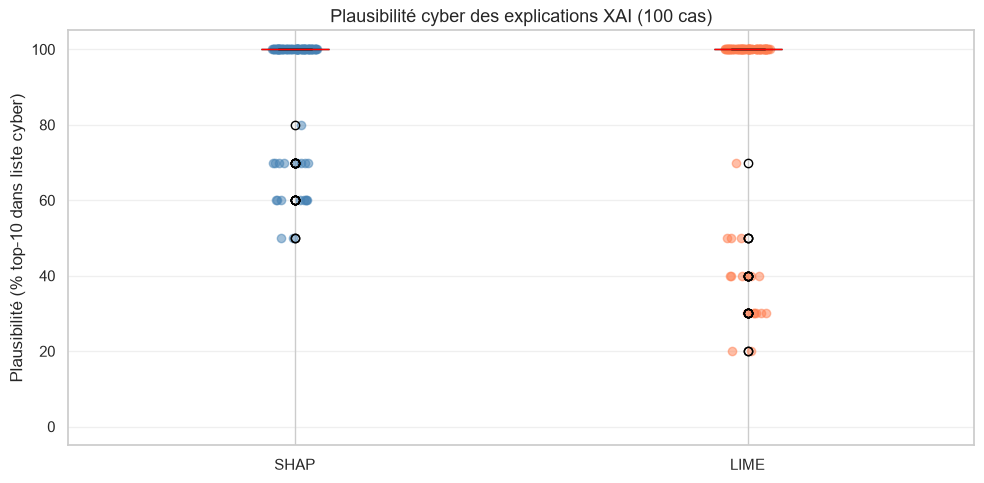

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([shap_plausibility*100, lime_plausibility*100], tick_labels=['SHAP', 'LIME'],
           patch_artist=True, boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
ax.scatter(np.ones_like(shap_plausibility) + np.random.uniform(-0.05, 0.05, len(shap_plausibility)),
            shap_plausibility*100, color='steelblue', alpha=0.5)
ax.scatter(2*np.ones_like(lime_plausibility) + np.random.uniform(-0.05, 0.05, len(lime_plausibility)),
            lime_plausibility*100, color='coral', alpha=0.5)
ax.set_ylabel('Plausibilité (% top-10 dans liste cyber)')
ax.set_title(f'Plausibilité cyber des explications XAI ({n_fidelity_cases} cas)', fontsize=13)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '10_xai_plausibility.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthèse : le verdict final

Tableau récapitulatif sur les 3 métriques.

In [16]:
synthesis = pd.DataFrame({
    'Métrique': ['Stabilité (Jaccard)', 'Fidélité (AOPC)', 'Plausibilité (% cyber)'],
    'SHAP': [
        f'{shap_stability.mean():.4f}',
        f'{shap_aopc_means.mean():.4f}',
        f'{shap_plausibility.mean()*100:.1f}%',
    ],
    'LIME': [
        f'{lime_stability.mean():.4f}',
        f'{lime_aopc_means.mean():.4f}',
        f'{lime_plausibility.mean()*100:.1f}%',
    ],
    'Vainqueur': [
        'SHAP' if shap_stability.mean() > lime_stability.mean() else 'LIME',
        'SHAP' if shap_aopc_means.mean() > lime_aopc_means.mean() else 'LIME',
        'SHAP' if shap_plausibility.mean() > lime_plausibility.mean() else 'LIME',
    ],
})

print('=' * 80)
print(f'  ÉVALUATION COMPARATIVE QUALITÉ DES EXPLICATIONS XAI')
print('=' * 80)
print(synthesis.to_string(index=False))
print('=' * 80)

synthesis.to_csv(RESULTS_METRICS / 'xai_quality_evaluation.csv', index=False)

  ÉVALUATION COMPARATIVE QUALITÉ DES EXPLICATIONS XAI
              Métrique   SHAP   LIME Vainqueur
   Stabilité (Jaccard) 1.0000 0.5649      SHAP
       Fidélité (AOPC) 0.1186 0.1150      SHAP
Plausibilité (% cyber)  93.2%  88.1%      SHAP


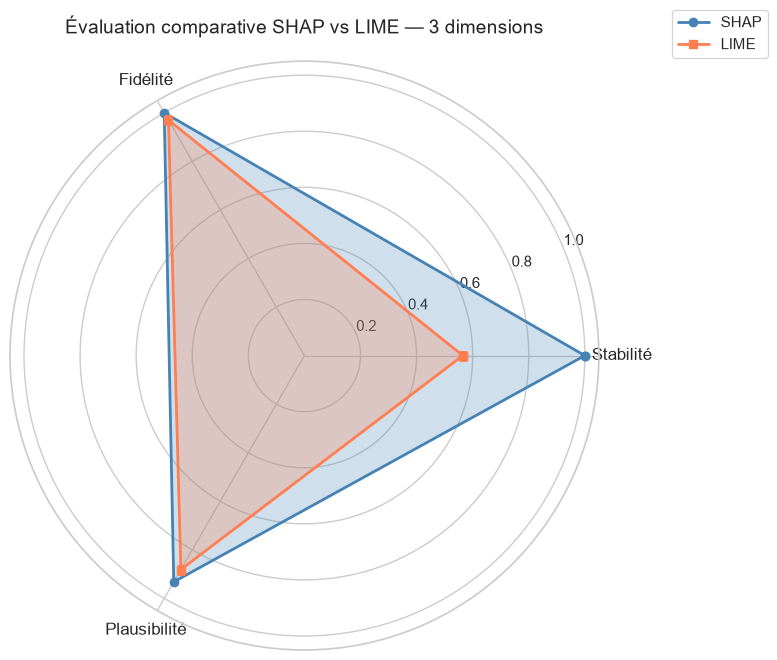

In [17]:
# Graphique radar comparatif
# On normalise chaque métrique sur [0, 1] pour la comparaison radar
metrics_norm = {
    'Stabilité': (shap_stability.mean(), lime_stability.mean()),
    'Fidélité': (
        shap_aopc_means.mean() / max(shap_aopc_means.mean(), lime_aopc_means.mean(), 1e-9),
        lime_aopc_means.mean() / max(shap_aopc_means.mean(), lime_aopc_means.mean(), 1e-9),
    ),
    'Plausibilité': (shap_plausibility.mean(), lime_plausibility.mean()),
}

labels = list(metrics_norm.keys())
shap_scores = [metrics_norm[k][0] for k in labels]
lime_scores = [metrics_norm[k][1] for k in labels]

# Radar plot
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
shap_scores += shap_scores[:1]
lime_scores += lime_scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, shap_scores, 'o-', linewidth=2, label='SHAP', color='steelblue')
ax.fill(angles, shap_scores, alpha=0.25, color='steelblue')
ax.plot(angles, lime_scores, 's-', linewidth=2, label='LIME', color='coral')
ax.fill(angles, lime_scores, alpha=0.25, color='coral')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('Évaluation comparative SHAP vs LIME — 3 dimensions', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '10_xai_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎉 Récapitulatif

Tu viens de produire **l'évaluation comparative rigoureuse SHAP vs LIME** la plus complète possible dans un cadre PFE.

### Outputs produits

**Figures pour le rapport :**
- `10_xai_stability.png` : boxplot stabilité
- `10_xai_fidelity_aopc.png` : courbe AOPC + boxplot
- `10_xai_plausibility.png` : boxplot plausibilité
- `10_xai_radar_comparison.png` : radar synthétique

**Données :**
- `xai_quality_evaluation.csv` : tableau récapitulatif

### Ce que ça permet d'écrire dans ton rapport

Une **section 5.5** complète avec :
1. Méthodologie d'évaluation (3 métriques de la littérature XAI)
2. Résultats quantitatifs
3. **Recommandation argumentée** d'une méthode
4. Discussion des limites

### Prochaine étape (notebook 11)

**Validation sur UNSW-NB15** : on prend ton modèle XGBoost optimisé et on regarde s'il généralise sur un autre dataset de cybersécurité (différent réseau, différentes années).

C'est ce qui va répondre à la question : *"Ce modèle marche-t-il vraiment en général, ou est-il bon que sur CIC-IDS2017 ?"*